In [46]:
#Level 1
#Task 1
#Task: Top Cuisines
# Question 1: Determine the top three most common cuisines in the dataset.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# 1. Prepare Cuisines data: Handle NaNs and split combined cuisines
cuisines_series = df['Cuisines'].dropna()

# Split the combined cuisine strings (e.g., "North Indian, Chinese") into separate entries
# .str.split(', ') splits the string into a list of cuisines
# .apply(pd.Series).stack() converts the lists into a single, long Series for counting
all_cuisines = cuisines_series.str.split(', ').apply(pd.Series).stack().str.strip()

# 2. Count the frequency of each individual cuisine
cuisine_counts = all_cuisines.value_counts()

# 3. Determine the top 3 most common cuisines
top_3_cuisines = cuisine_counts.head(3)

print("--- Top 3 Most Common Individual Cuisines ---")
print(top_3_cuisines.to_string())

--- Top 3 Most Common Individual Cuisines ---
North Indian    3960
Chinese         2735
Fast Food       1986


In [47]:
# Question 2: Calculate the percentage of restaurants that serve each of the top cuisines
import pandas as pd

# Read dataset
df = pd.read_csv("Dataset .csv")

# Split and clean cuisines
cuisine_counts = (
    df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

# Get top cuisines
top_cuisines = cuisine_counts.head(3)

# Total number of restaurants (rows)
total_restaurants = len(df)

# Calculate percentage
cuisine_percentages = (top_cuisines / total_restaurants) * 100

print("Percentage of Restaurants Serving Each Top Cuisine:\n")
for cuisine, pct in cuisine_percentages.items():
    print(f"{cuisine}: {pct:.2f}%")


Percentage of Restaurants Serving Each Top Cuisine:

North Indian: 41.46%
Chinese: 28.64%
Fast Food: 20.79%


In [44]:
#level 1
#task 2-city anaylsis
# Question 1: Identify the city with the highest number of restaurants
import pandas as pd

# Read dataset
df = pd.read_csv("Dataset .csv")

# Count number of restaurants per city
city_counts = df['City'].value_counts()

# Get city with the highest number of restaurants
top_city = city_counts.idxmax()
top_city_count = city_counts.max()

print(f"City with the highest number of restaurants: {top_city} ({top_city_count} restaurants)")


City with the highest number of restaurants: New Delhi (5473 restaurants)


In [45]:
# Question 2: Calculate the average rating for restaurants in each city
import pandas as pd

# Read dataset
df = pd.read_csv("Dataset .csv")

# Group by City and calculate mean rating
avg_rating_per_city = (
    df.groupby('City')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
)

# Display results
print("Average Rating for Restaurants in Each City:\n")
print(avg_rating_per_city)


Average Rating for Restaurants in Each City:

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64


In [4]:
# Question 3: Determine the city with the highest average rating
import pandas as pd

# Read dataset
df = pd.read_csv("Dataset .csv")

# Calculate average rating per city
avg_rating_per_city = df.groupby('City')['Aggregate rating'].mean()

# Find city with the highest average rating
top_rated_city = avg_rating_per_city.idxmax()
highest_avg_rating = avg_rating_per_city.max()

print(f"City with the highest average rating: {top_rated_city} ({highest_avg_rating:.2f})")


City with the highest average rating: Inner City (4.90)


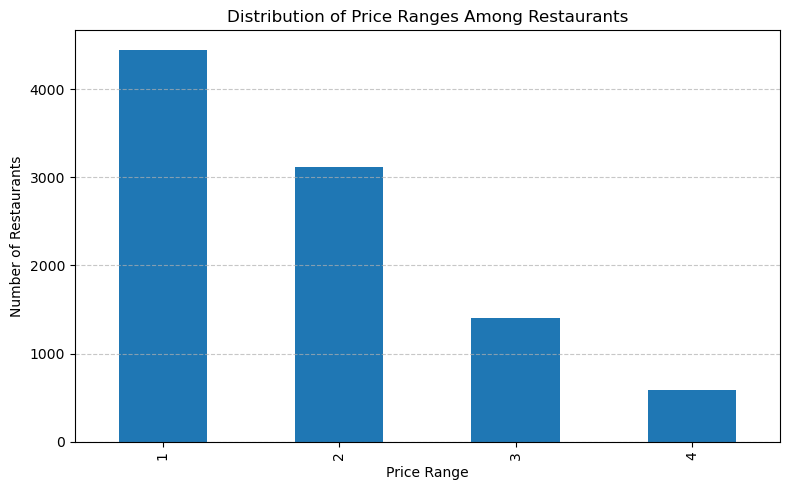

In [5]:
#Level 1
#Task 3
#Task: Price Range Distribution
# Question 1: Visualize the distribution of price ranges among restaurants
import pandas as pd
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv("Dataset .csv")

# Plot the distribution of 'Price range'
plt.figure(figsize=(8,5))
df['Price range'].value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Price Ranges Among Restaurants")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [6]:
# Question 2: Calculate the percentage of restaurants in each price range category
import pandas as pd

# Read dataset
df = pd.read_csv("Dataset .csv")

# Calculate counts of each price range
price_counts = df['Price range'].value_counts().sort_index()

# Calculate percentage
price_percentages = (price_counts / len(df)) * 100

# Display results
print("Percentage of Restaurants in Each Price Range Category:\n")
for price, pct in price_percentages.items():
    print(f"Price Range {price}: {pct:.2f}%")


Percentage of Restaurants in Each Price Range Category:

Price Range 1: 46.53%
Price Range 2: 32.59%
Price Range 3: 14.74%
Price Range 4: 6.14%


In [7]:
#Level 1
#Task 4
#Task: Online Delivery
# Question 1: Determine the percentage of restaurants that offer online delivery
import pandas as pd

# Read dataset
df = pd.read_csv("Dataset .csv")

# Calculate total and "Yes" counts
total_restaurants = len(df)
online_delivery_yes = (df['Has Online delivery'].str.lower() == 'yes').sum()

# Calculate percentage
online_delivery_percentage = (online_delivery_yes / total_restaurants) * 100

print(f"Percentage of restaurants that offer online delivery: {online_delivery_percentage:.2f}%")


Percentage of restaurants that offer online delivery: 25.66%


In [8]:
# Question 2: Determine the percentage of restaurants that offer online delivery.

import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# Calculate the percentage
total_restaurants = len(df)
online_delivery_yes = (df['Has Online delivery'] == 'Yes').sum()
online_delivery_percentage = (online_delivery_yes / total_restaurants) * 100

print(f"Percentage of restaurants that offer online delivery: {online_delivery_percentage:.2f}%")

Percentage of restaurants that offer online delivery: 25.66%


In [10]:
## Question 3: Compare the average ratings of restaurants with and without online delivery.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# Group the data by the 'Has Online delivery' column
# and calculate the mean of 'Aggregate rating' for each group.
average_ratings = df.groupby('Has Online delivery')['Aggregate rating'].mean().reset_index()

# Print the comparison
print("--- Average Rating Comparison ---")
print(average_ratings)

--- Average Rating Comparison ---
  Has Online delivery  Aggregate rating
0                  No          2.465296
1                 Yes          3.248837


In [13]:
#Level 2
#Task 1
#Task: Restaurant Rating
# Question 1: Analyze the distribution of aggregate ratings and determine the most common rating range.

import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# --- 1. Most Common Rating Range (based on 'Rating text') ---

# The 'Rating text' column groups ratings into ranges (e.g., 'Average', 'Good', 'Excellent').
# We use this to find the most common range.
rating_text_distribution = df['Rating text'].value_counts()

# The top entry is the most common range.
most_common_range = rating_text_distribution.index[0]
count_of_most_common = rating_text_distribution.iloc[0]

# --- 2. Most Common Single Rating (based on 'Aggregate rating') ---

# We also check the distribution of the raw numeric rating.
single_rating_distribution = df['Aggregate rating'].value_counts()

most_common_single_rating = single_rating_distribution.index[0]
count_of_single_common = single_rating_distribution.iloc[0]


# --- Print Results ---
print("--- Distribution Analysis ---")
print("\nMost Common Rating Range (Category):")
print(f"Range: '{most_common_range}'")
print(f"Count: {count_of_most_common} restaurants")

print("\nFull Rating Text Distribution:")
print(rating_text_distribution)

print("\nMost Common Single Numeric Rating (Mode):")
# Note: A 0.0 rating often means 'Not Rated'
print(f"Rating: {most_common_single_rating}")
print(f"Count: {count_of_single_common} restaurants")

--- Distribution Analysis ---

Most Common Rating Range (Category):
Range: 'Average'
Count: 3737 restaurants

Full Rating Text Distribution:
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

Most Common Single Numeric Rating (Mode):
Rating: 0.0
Count: 2148 restaurants


In [15]:
# Question 2: Calculate the average number of votes received by restaurants.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# Calculate the mean of the 'Votes' column
average_votes = df['Votes'].mean()

# Print the result, formatted to two decimal places
print(f"The average number of votes received by restaurants is: {average_votes:.2f}")

The average number of votes received by restaurants is: 156.91


In [17]:
#Level 2
#Task 2
#Task: Cuisine Combination
# Question 1: Identify the most common combinations of cuisines in the dataset.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# Drop rows where 'Cuisines' is missing (NaN) as they don't have a combination.
cuisines_data = df['Cuisines'].dropna()

# Use value_counts() to count the occurrences of each unique combination (string)
# and get the top 10 most frequent ones.
most_common_combinations = cuisines_data.value_counts().head(10)

# Print the results in a readable format
print("--- Top 10 Most Common Combinations of Cuisines ---")
print(most_common_combinations.to_string())

--- Top 10 Most Common Combinations of Cuisines ---
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149


In [19]:
# Question 2: Determine if certain cuisine combinations tend to have higher ratings.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# Calculate the average rating and count for each unique cuisine combination
cuisine_analysis = df.groupby('Cuisines').agg(
    Average_Rating=('Aggregate rating', 'mean'),
    Count=('Cuisines', 'size')
).reset_index()

# Filter combinations that appear more than 50 times (Count > 50)
# to ensure the average ratings are statistically more reliable (i.e., not based on just 1 or 2 restaurants).
COUNT_THRESHOLD = 50
filtered_analysis = cuisine_analysis[cuisine_analysis['Count'] > COUNT_THRESHOLD]

# Sort the filtered results by 'Average_Rating' in descending order
highest_rated_cuisines = filtered_analysis.sort_values(
    by='Average_Rating', ascending=False
).head(10)

# Display the results
print("Top 10 Cuisine Combinations with Highest Average Ratings (Count > 50):")
print(highest_rated_cuisines.to_string(index=False))

Top 10 Cuisine Combinations with Highest Average Ratings (Count > 50):
                                Cuisines  Average_Rating  Count
                                 Italian        3.657407     54
                       Fast Food, Burger        3.403571     56
             Bakery, Desserts, Fast Food        3.366667     63
                           Chinese, Thai        3.309804     51
      North Indian, Chinese, Continental        3.036923     65
American, Fast Food, Salad, Healthy Food        2.900000     62
                                    Cafe        2.890970    299
                   North Indian, Mughlai        2.888623    334
                     Ice Cream, Desserts        2.774699     83
          North Indian, Chinese, Mughlai        2.740000     70


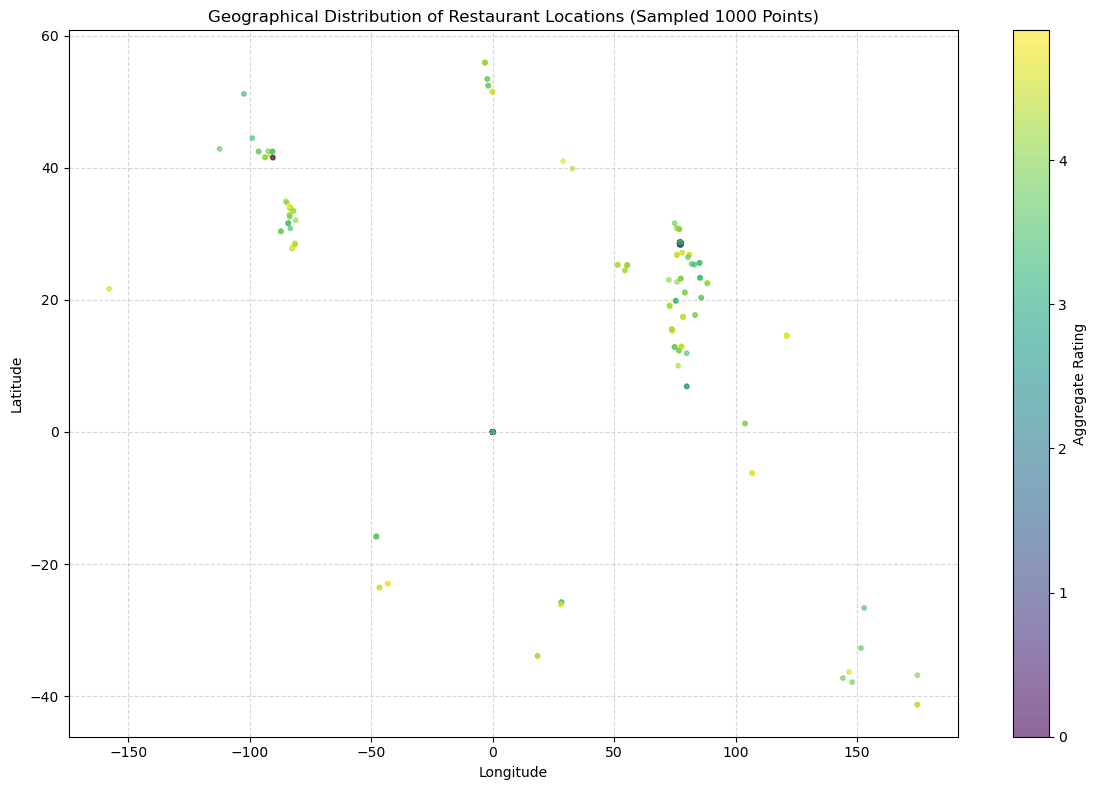

In [21]:
#Level 2
#Task 3
#Task: Geographic Analysis
# Question 1: Plot the locations of restaurants on a map using longitude and latitude coordinates.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Dataset .csv")

# Clean and sample the data (1000 points)
df_map = df.dropna(subset=['Latitude', 'Longitude']).copy()
np.random.seed(42) 
sample_size = min(1000, len(df_map))
df_sample = df_map.sample(sample_size)

# Create a scatter plot
plt.figure(figsize=(12, 8))
# Color points by Aggregate rating using the 'viridis' colormap
plt.scatter(df_sample['Longitude'], df_sample['Latitude'], 
            s=10, 
            c=df_sample['Aggregate rating'], 
            cmap='viridis', 
            alpha=0.6)

# Add color bar for rating
cbar = plt.colorbar()
cbar.set_label('Aggregate Rating')

plt.title(f'Geographical Distribution of Restaurant Locations (Sampled {sample_size} Points)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the plot
plt.savefig('restaurant_locations_scatter.png')

In [23]:
# Question 2: Identify any patterns or clusters of restaurants in specific areas.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# 1. Analyze concentration by City
city_clusters = df['City'].value_counts().head(10)

# 2. Analyze concentration by Locality (smaller, specific area clusters)
locality_clusters = df['Locality'].value_counts().head(10)

print("--- Top 10 Cities (Major Clusters) by Restaurant Count ---")
print(city_clusters.to_string())
print("\n--- Top 10 Localities (Specific Area Clusters) by Restaurant Count ---")
print(locality_clusters.to_string())

--- Top 10 Cities (Major Clusters) by Restaurant Count ---
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21

--- Top 10 Localities (Specific Area Clusters) by Restaurant Count ---
Locality
Connaught Place        122
Rajouri Garden          99
Shahdara                87
Defence Colony          86
Malviya Nagar           85
Pitampura               85
Mayur Vihar Phase 1     84
Rajinder Nagar          81
Safdarjung              80
Satyaniketan            79


In [25]:
#Level 2
#Task 4
#Task: Restaurant Chains
# Question 1: Identify if there are any restaurant chains present in the dataset.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# Identify restaurant chains by counting occurrences of 'Restaurant Name'.
# A name appearing more than once suggests multiple branches (a chain).
chain_counts = df['Restaurant Name'].value_counts()

# Filter for names that appear more than once
restaurant_chains = chain_counts[chain_counts > 1]

# Get the top 10 chains
top_chains = restaurant_chains.sort_values(ascending=False).head(10)

# Calculate summary statistics
total_chains = len(restaurant_chains)
total_chain_restaurants = restaurant_chains.sum()

# Print the results
print("--- Top 10 Restaurant Chains (Names appearing more than once) ---")
print(top_chains.to_string())

print(f"\nTotal number of restaurant chains identified: {total_chains}")
print(f"Total number of entries belonging to a chain: {total_chain_restaurants}")

--- Top 10 Restaurant Chains (Names appearing more than once) ---
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26

Total number of restaurant chains identified: 734
Total number of entries belonging to a chain: 2839


In [27]:
# Question 2: Analyze the ratings and popularity of different restaurant chains.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# 1. Identify Chains
chain_counts = df['Restaurant Name'].value_counts()
restaurant_chains = chain_counts[chain_counts > 1].index

# Filter the main DataFrame to include only chain restaurants
df_chains = df[df['Restaurant Name'].isin(restaurant_chains)]

# 2. Analyze Chains
chain_analysis = df_chains.groupby('Restaurant Name').agg(
    Popularity=('Restaurant Name', 'size'),  # Number of outlets
    Average_Rating=('Aggregate rating', 'mean'),  # Quality indicator
    Total_Votes=('Votes', 'sum')  # Total customer engagement
).reset_index()

# 3. Sort and Display Results
chain_analysis_sorted = chain_analysis.sort_values(
    by=['Popularity', 'Average_Rating'], ascending=[False, False]
)

top_15_chains = chain_analysis_sorted.head(15)

print("--- Top 15 Restaurant Chains by Popularity and Average Rating ---")
print(top_15_chains.to_string(index=False))

--- Top 15 Restaurant Chains by Popularity and Average Rating ---
 Restaurant Name  Popularity  Average_Rating  Total_Votes
 Cafe Coffee Day          83        2.419277         2428
  Domino's Pizza          79        2.740506         6643
          Subway          63        2.907937         6124
Green Chick Chop          51        2.672549          964
      McDonald's          48        3.339583         5291
       Keventers          34        2.870588         1263
       Pizza Hut          30        3.320000         4961
           Giani          29        2.689655          854
  Baskin Robbins          28        1.860714          428
 Barbeque Nation          26        4.353846        28142
  Dunkin' Donuts          22        3.136364         5974
         Barista          22        3.072727          815
         Giani's          22        2.781818         1150
   Pind Balluchi          20        2.630000         5582
    Costa Coffee          20        2.415000          861


In [29]:
#Level 3
#Task 1
#Task: Restaurant Reviews
# Question 1: Analyze the text reviews to identify the most common positive and negative keywords.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# Function to analyze common individual cuisines for a given rating text
def get_top_cuisines_by_rating(dataframe, rating_text, top_n=10):
    # Filter by Rating Text
    filtered_df = dataframe[dataframe['Rating text'].str.lower() == rating_text.lower()].copy()
    
    # Handle NaN values in Cuisines and split the string into individual cuisines
    cuisines_series = filtered_df['Cuisines'].dropna().str.split(', ')
    
    # Stack the list of cuisines into a single series for counting
    all_cuisines = cuisines_series.apply(pd.Series).stack().str.strip()
    
    # Get the value counts
    top_cuisines = all_cuisines.value_counts().head(top_n)
    
    return top_cuisines

# 1. Analysis for "Positive" Proxy: 'Excellent' Rating
top_positive_cuisines = get_top_cuisines_by_rating(df, 'Excellent', top_n=10)

# 2. Analysis for "Negative" Proxy: 'Poor' Rating
top_negative_cuisines = get_top_cuisines_by_rating(df, 'Poor', top_n=10)

print("--- Top 10 Cuisines Associated with 'Excellent' Rating (Positive Proxy) ---")
print(top_positive_cuisines.to_string())

print("\n--- Top 10 Cuisines Associated with 'Poor' Rating (Negative Proxy) ---")
print(top_negative_cuisines.to_string())

--- Top 10 Cuisines Associated with 'Excellent' Rating (Positive Proxy) ---
North Indian    47
American        44
Italian         38
Cafe            38
Desserts        31
Continental     31
Asian           25
Chinese         23
Burger          21
Seafood         21

--- Top 10 Cuisines Associated with 'Poor' Rating (Negative Proxy) ---
North Indian    96
Chinese         78
Fast Food       63
Mughlai         28
Pizza           27
South Indian    20
Italian         13
Bakery          12
American        12
Street Food      9


In [31]:
# Question 1: Calculate the average length of reviews and explore if there is a relationship between review length and rating.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# --- IMPORTANT: THIS CODE ASSUMES A COLUMN NAMED 'Review Text' EXISTS ---

# 1. Calculate the length of each review
if 'Review Text' in df.columns:
    df['Review Length'] = df['Review Text'].str.len()
    
    # 2. Calculate the average length of all reviews
    average_length = df['Review Length'].mean()
    print(f"1. The average length of reviews is: {average_length:.2f} characters.")
    
    # 3. Explore relationship: Calculate average length grouped by 'Rating text'
    length_by_rating = df.groupby('Rating text')['Review Length'].mean().sort_values(ascending=False)
    
    print("\n2. Average Review Length Grouped by Rating Text:")
    print(length_by_rating.to_string())
    
else:
    print("--- ERROR: Cannot perform review length analysis ---")
    print("The required 'Review Text' column is missing from the dataset.")

--- ERROR: Cannot perform review length analysis ---
The required 'Review Text' column is missing from the dataset.


In [33]:
#Level 3
#Task 2
#Task: Votes Analysis
# Question: Identify the restaurants with the highest and lowest number of votes.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# 1. Identify restaurant(s) with the highest number of votes
highest_votes_restaurants = df.sort_values(by='Votes', ascending=False).head(5)

# 2. Identify restaurant(s) with the lowest number of votes
lowest_votes_restaurants = df.sort_values(by='Votes', ascending=True).head(5)

# Select only relevant columns for printing
cols_to_display = ['Restaurant Name', 'City', 'Aggregate rating', 'Votes']

print("--- Top 5 Restaurants with the HIGHEST Number of Votes ---")
print(highest_votes_restaurants[cols_to_display].to_string(index=False))

print("\n--- Top 5 Restaurants with the LOWEST Number of Votes (including 0 votes) ---")
print(lowest_votes_restaurants[cols_to_display].to_string(index=False))

--- Top 5 Restaurants with the HIGHEST Number of Votes ---
          Restaurant Name      City  Aggregate rating  Votes
                     Toit Bangalore               4.8  10934
                 Truffles Bangalore               4.7   9667
         Hauz Khas Social New Delhi               4.3   7931
                Peter Cat   Kolkata               4.3   7574
AB's - Absolute Barbecues Bangalore               4.6   6907

--- Top 5 Restaurants with the LOWEST Number of Votes (including 0 votes) ---
           Restaurant Name      City  Aggregate rating  Votes
       Khalsa Eating Point New Delhi               0.0      0
 Radha Swami Chaat Bhandar New Delhi               0.0      0
Ram Ram Ji Kachori Bhandar New Delhi               0.0      0
        Rana's Food Corner New Delhi               0.0      0
       Sanjay Chicken Shop New Delhi               0.0      0


Pearson Correlation Coefficient between Votes and Aggregate Rating: 0.3137


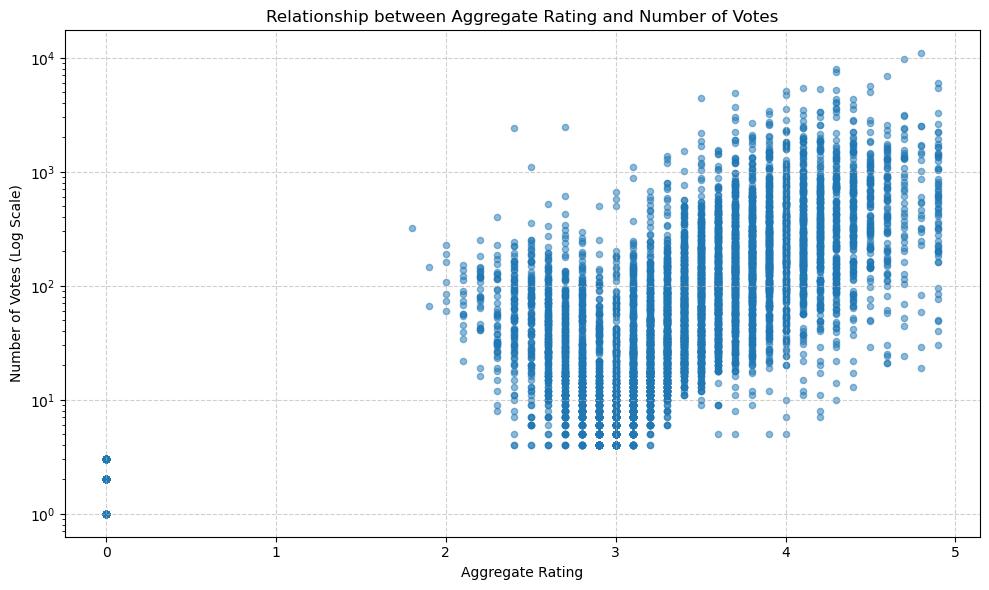

In [36]:
# Question 2: Analyze if there is a correlation between the number of votes and the rating of a restaurant.
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Dataset .csv")

# 1. Calculate the Pearson correlation coefficient
correlation = df['Votes'].corr(df['Aggregate rating'])

# 2. Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
# Use a logarithmic scale for Votes to handle the large skew in the data
plt.scatter(df['Aggregate rating'], df['Votes'], alpha=0.5, s=20)
plt.yscale('log') # Log scale helps spread out the lower vote counts

plt.title('Relationship between Aggregate Rating and Number of Votes')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Votes (Log Scale)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig('rating_vs_votes_scatter.png')

print(f"Pearson Correlation Coefficient between Votes and Aggregate Rating: {correlation:.4f}")

In [38]:
#Level 3
#Task 3
#Task: Price Range vs. Online Delivery and Table Booking
# Question 1: Analyze if there is a relationship between the price range and the availability of online delivery and table booking.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# 1. Relationship between Price Range and Online Delivery
delivery_by_price = df.groupby('Price range')['Has Online delivery'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# 2. Relationship between Price Range and Table Booking
booking_by_price = df.groupby('Price range')['Has Table booking'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

print("--- Percentage of Restaurants by Price Range and Online Delivery ---")
print(delivery_by_price.round(2).to_string())

print("\n--- Percentage of Restaurants by Price Range and Table Booking ---")
print(booking_by_price.round(2).to_string())

--- Percentage of Restaurants by Price Range and Online Delivery ---
Has Online delivery     No    Yes
Price range                      
1                    84.23  15.77
2                    58.69  41.31
3                    70.81  29.19
4                    90.96   9.04

--- Percentage of Restaurants by Price Range and Table Booking ---
Has Table booking     No    Yes
Price range                    
1                  99.98   0.02
2                  92.32   7.68
3                  54.26  45.74
4                  53.24  46.76


In [40]:
# Question 2: Determine if higher-priced restaurants are more likely to offer these services.
import pandas as pd

# Load the dataset
df = pd.read_csv("Dataset .csv")

# 1. Percentage of restaurants offering Online Delivery by Price Range
delivery_by_price = df.groupby('Price range')['Has Online delivery'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

# 2. Percentage of restaurants offering Table Booking by Price Range
booking_by_price = df.groupby('Price range')['Has Table booking'].value_counts(normalize=True).mul(100).unstack(fill_value=0)

print("--- Percentage of Restaurants Offering Online Delivery by Price Range ---")
print(delivery_by_price.round(2).to_string())

print("\n--- Percentage of Restaurants Offering Table Booking by Price Range ---")
print(booking_by_price.round(2).to_string())

--- Percentage of Restaurants Offering Online Delivery by Price Range ---
Has Online delivery     No    Yes
Price range                      
1                    84.23  15.77
2                    58.69  41.31
3                    70.81  29.19
4                    90.96   9.04

--- Percentage of Restaurants Offering Table Booking by Price Range ---
Has Table booking     No    Yes
Price range                    
1                  99.98   0.02
2                  92.32   7.68
3                  54.26  45.74
4                  53.24  46.76
